# Week 1 · Notebook 1 — The data, and your first tool

Welcome. Over three weeks you'll build a real algorithmic trading system: it reads
the market, forms strategies, tests them honestly, and — by week 3 — *learns* to
trade. Everything compounds; nothing you build gets thrown away.

Today is the gentlest day on purpose. Two goals:
1. Understand **the environment** — the world your strategies will live in.
2. Build your **first tool**: a price-charting function you'll reuse all week.

If your setup works and you draw a chart by the end, today succeeded.

In [ ]:
import sys, os

while not os.path.isdir("src") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")

sys.path.insert(0, "src")

import numpy as np
import matplotlib.pyplot as plt

from tradinglab.data_feed import DataFeed

feed = DataFeed.from_dir("data/egx")

print(feed.symbols)

## 1. The environment: what your strategies see

Every strategy in this program acts inside one shared world — a `DataFeed`. Think
of it as the market, frozen into a table you can query. It holds, for a whole
universe of stocks aligned to the same calendar:

- `feed.close` — closing prices, shape **(days × stocks)**
- `feed.returns` — daily returns (how much each stock moved), same shape
- `feed.volume` — how much traded

This is the single source of truth. Indicators read from it, strategies act on it,
the backtester walks through it day by day, and in week 3 the reinforcement-learning
agent will live inside it too. Learn its shape now and everything later is familiar.

In [ ]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')
import numpy as np
import matplotlib.pyplot as plt

from tradinglab.data_feed import DataFeed

feed = DataFeed.from_dir('data/egx')
print('universe :', feed.symbols)
print('days     :', feed.n_days)
print('close is a table of shape (days, stocks):', feed.close.shape)
print()
print('last 5 closing prices of', feed.symbols[0], ':', feed.close[-5:, 0].round(2))
print('its last 5 daily returns             :', feed.returns[-5:, 0].round(4))

""" files = os.listdir("data/egx")
print(files[:10])   # show the first 10 files """

In [ ]:
import pandas as pd
import mplfinance as mpf

df = pd.read_csv("data/egx/COMI.csv")

In [ ]:
df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)

In [ ]:
df = df.rename(columns={
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
    "volume": "Volume"
})

In [ ]:
mpf.plot(
    df,
    type="candle",
    style="yahoo",
    volume=True,
    title="COMI",
    figsize=(14, 7)
)

# Candlestick Chart Visualization

In this section, we visualize the historical price movement of **ABUK** using a **candlestick chart**.

### Objective
- Load the raw stock data from `ABUK.csv`.
- Filter the dataset to include only observations between **2022** and **2026**.
- Convert the data into the format required by `mplfinance`.
- Plot:
  -  Candlesticks (Open, High, Low, Close)
  -  Trading Volume
  -  20-day and 50-day Simple Moving Averages (SMA)

### Why Candlestick Charts?

Unlike a simple line chart that only displays the closing price, a candlestick chart summarizes four important prices for each trading day:

- **Open**
- **High**
- **Low**
- **Close**

This provides a much richer view of market behavior and is one of the most widely used visualizations in quantitative finance and technical analysis.

In [ ]:
import pandas as pd
import mplfinance as mpf

# Load ABUK data
df = pd.read_csv("data/egx/ABUK.csv")

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Keep only data between 2022 and 2026
df = df[(df["date"] >= "2022-01-01") & (df["date"] <= "2026-12-31")]

# Set date as the index
df.set_index("date", inplace=True)

# Rename columns for mplfinance
df.rename(columns={
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
    "volume": "Volume"
}, inplace=True)

# Plot candlestick chart
mpf.plot(
    df,
    type="candle",
    style="yahoo",
    volume=True,
    title="ABUK (2022 => 2026)",
    ylabel="Price (EGP)",
    ylabel_lower="Volume",
    figsize=(14, 8),
    mav=(20, 50),      # 20-day and 50-day moving averages
    tight_layout=True
)

## 2. Your first tool — `plot_price`

You'll look at prices constantly, so build a reusable chart function. Given the
figure is already set up for you, fill in the drawing: plot the closing price, then
plot each optional overlay (like a moving average) on top.

**In:** `dates`, `close`, and an optional `overlays` dict like `{'SMA20': array}`.
**Out:** the chart's `ax` (already returned for you).
**Hint:** `ax.plot(dates, close, label='close')`, then loop over `overlays.items()`.
**Done when:** the check counts the right number of lines.

In [ ]:
def plot_price(dates, close, overlays=None, title='Price'):
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(dates, close, label='close', linewidth=1.2)
    for name, series in (overlays or {}).items():
        ax.plot(dates, series, label=name, linewidth=1.0)
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    return ax

ax = plot_price(feed.dates, feed.close[:, 0],
                overlays={'flat line': np.full(feed.n_days, feed.close[:,0].mean())},
                title=feed.symbols[0])
assert len(ax.lines) == 2, 'expected close + 1 overlay'
plt.show()
print('plot_price works ✓ — this is your chart tool for the whole week')

#  Comparing Simple Moving Average (SMA) and Exponential Moving Average (EMA)

## Objective

In this section, we compare two of the most widely used trend-following indicators in technical analysis:

- **Simple Moving Average (SMA)**
- **Exponential Moving Average (EMA)**

Both indicators help smooth short-term price fluctuations and make the underlying market trend easier to identify.

---

## Indicators Used

###  Simple Moving Average (SMA)

The Simple Moving Average calculates the arithmetic mean of the closing prices over a fixed number of trading days.

For a 20-day SMA:

\[
SMA_{20}=\frac{P_1+P_2+\cdots+P_{20}}{20}
\]

Every observation contributes equally to the average.

---

###  Exponential Moving Average (EMA)

The Exponential Moving Average assigns greater weight to recent prices, allowing it to react more quickly to changes in market conditions.

Unlike the SMA, the EMA emphasizes the latest market information while still considering historical prices.

---

## Visualization

The chart below displays:

-  Daily candlesticks
-  20-day Simple Moving Average (SMA 20)
-  20-day Exponential Moving Average (EMA 20)
-  Daily trading volume


the real visualization from tradingview
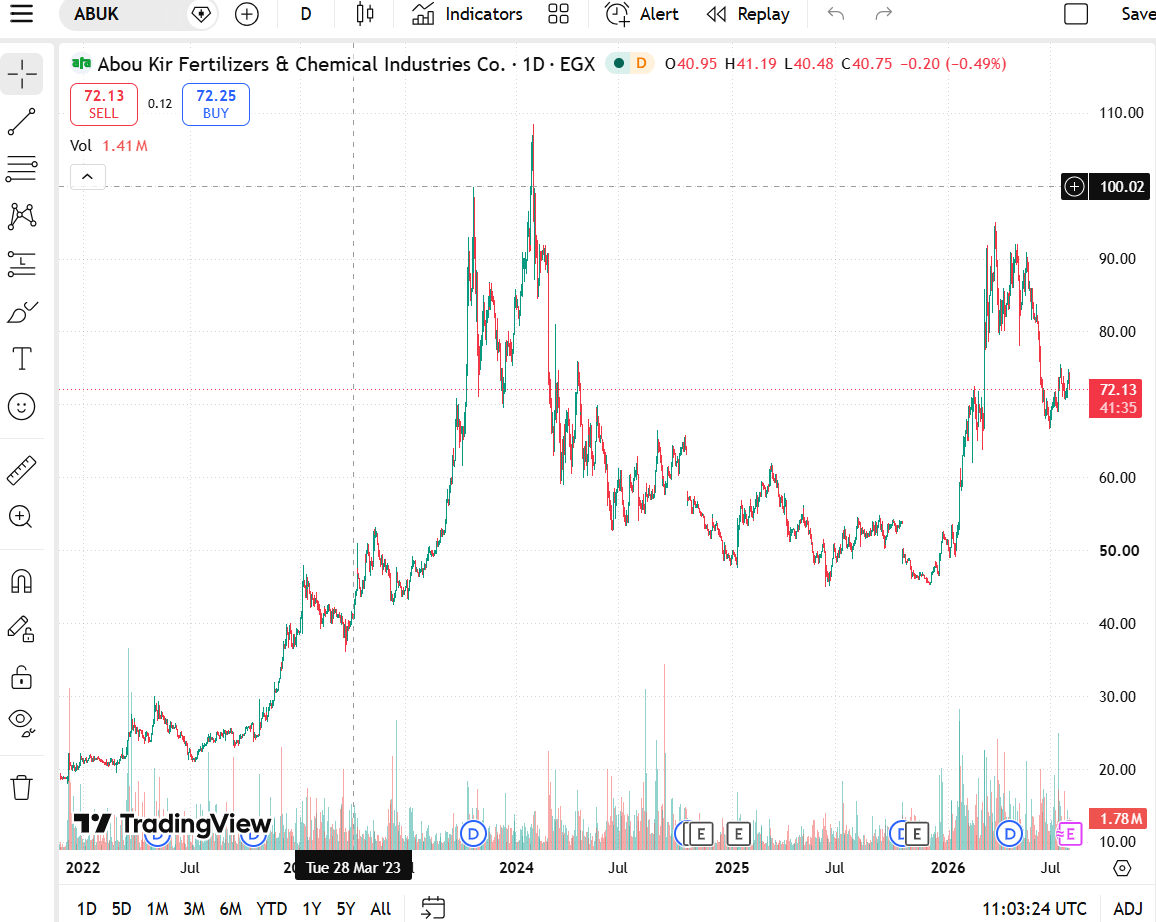

In [ ]:
df["SMA20"] = df["Close"].rolling(20).mean()

df["EMA20"] = df["Close"].ewm(span=20).mean()

In [ ]:
import mplfinance as mpf

apds = [
    mpf.make_addplot(df["SMA20"], label="SMA 20"),
    mpf.make_addplot(df["EMA20"], label="EMA 20"),
]

fig, ax = mpf.plot(
    df,
    type="candle",
    style="charles",
    volume=True,
    addplot=apds,
    figsize=(14,8),
    title="SMA vs EMA",
    returnfig=True
)

ax[0].legend()

plt.show()

#  Trading Volume and 20-Day Volume Moving Average

## Objective

This visualization compares the daily trading volume with its 20-day moving average (Volume MA20).

While the daily volume bars show the number of shares traded each day, the moving average smooths short-term fluctuations and highlights the overall trend in trading activity.

---

## Indicators

###  Daily Trading Volume

The bar chart represents the total number of shares traded on each trading day.

Large bars indicate periods of high market participation, while smaller bars indicate lower trading activity.

---

###  20-Day Volume Moving Average (Volume MA20)

The 20-day Volume Moving Average is calculated as the average trading volume over the previous 20 trading days.

It provides a baseline for determining whether the current trading volume is unusually high or unusually low.

\[
VolumeMA_{20}=\frac{V_1+V_2+\cdots+V_{20}}{20}
\]

where:

- \(V_i\) = Daily trading volume

---

## Interpretation

Compare the daily volume bars with the moving average line:

-  **Volume > Volume MA20**
  - Trading activity is higher than average.
  - Indicates increased investor participation.
  - May strengthen the significance of price movements.

-  **Volume < Volume MA20**
  - Trading activity is lower than average.
  - Indicates reduced market participation.
  - Price movements may carry less conviction.

---

## Expected Observations

While examining the chart, consider the following questions:

- Which periods exhibit unusually high trading volume?
- Are large price movements accompanied by increased volume?
- Are there extended periods of declining trading activity?
- Does the moving average reveal long-term trends in market participation?

Understanding volume behavior helps validate price trends and is an essential component of technical analysis and quantitative trading strategies.

In [ ]:
print(df.columns)

In [ ]:
df["Volume MA20"] = df["Volume"].rolling(20).mean()
plt.figure(figsize=(14,5))

plt.bar(df.index, df["Volume"], label="Daily Volume")
plt.plot(
    df.index,
    df["Volume MA20"],
    linewidth=2,
    label="20-Day Volume MA"
)

plt.title("ABUK Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


## 3. What you can do this week

Now that you can see the data, here's the arc:
- **Notebook 2** — build the indicators (moving average, RSI) that turn prices into
  signals.
- **Notebook 3** — turn signals into a strategy, and write the one function at the
  heart of the whole engine.
- **Notebook 4** — backtest your strategy and **report** the result honestly against
  the benchmark.
- **Notebook 5** — put it all on a dashboard.

**Graduate** `plot_price` into `src/tradinglab/charting.py` (replace the stub), then:
`uv run pytest week1/tests/`. Tomorrow you build the indicators that go on this
chart.